# FDConv vs WDConv: Frequency & Wavelet Dynamic Convolution Comparison

**BLM5103 - Computer Vision Project**

This notebook trains and compares three ResNet-18 variants on ImageNet-64x64:

| Variant | Conv Type | Domain | Key Module |
|---------|----------|--------|------------|
| **Baseline** | Standard Conv2d | Spatial | - |
| **FDConv** | Frequency Dynamic Conv (CVPR 2025) | Fourier | FFT + FBM + KSM |
| **WDConv** | Wavelet Dynamic Conv (Ours) | Wavelet | DWT + WBM + KSM |

**Pipeline:** Setup -> Dataset -> Models -> Training -> Benchmarks -> Visualization

---

## 0. Setup & Installation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Clone FDConv repo
!git clone https://github.com/Linwei-Chen/FDConv.git FDConv_repo 2>/dev/null || echo 'Already cloned'

# Install standard dependencies
!pip install -q torch torchvision timm tqdm matplotlib pandas numpy

# Patch FDConv.py to remove mmcv dependency
import os
fdconv_path = '/content/FDConv_repo/FDConv_detection/mmdet_custom/FDConv.py'
if os.path.exists(fdconv_path):
    with open(fdconv_path, 'r') as f:
        lines = f.readlines()

    with open(fdconv_path, 'w') as f:
        for line in lines:
            if 'from mmcv.cnn import CONV_LAYERS' in line:
                f.write('# Patched: Removed mmcv import\nCONV_LAYERS = {}\n')
            elif '@CONV_LAYERS.register_module()' in line:
                f.write('# Patched: Removed mmcv registration\n')
            else:
                f.write(line)
    print('FDConv.py patched successfully to remove mmcv dependency.')

Already cloned
FDConv.py patched successfully to remove mmcv dependency.


In [ ]:
import os
for root, dirs, files in os.walk('/content/FDConv_repo'):
    for f in files:
        if f == 'FDConv.py':
            print(os.path.join(root, f))

/content/FDConv_repo/FDConv_detection/mmdet_custom/FDConv.py


In [ ]:
import os, sys, json, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

# Add FDConv repo to path
FDCONV_SRC = os.path.join(os.getcwd(), 'FDConv_repo', 'FDConv_detection', 'mmdet_custom')
sys.path.insert(0, FDCONV_SRC)

# Import our modules
from engine import (
    seed_everything, ImageNet64Dataset, build_datasets, build_dataloaders,
    make_resnet18_64, count_params, replace_convs, build_all_models,
    train_variant, evaluate, benchmark_inference,
    save_json, load_json,
)
from FDConv import FDConv
from wdconv import WDConv

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    # Fixed: Changed total_mem to total_memory
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print("Python Version:", sys.version)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [ ]:
print("Python Version:", sys.version)

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 1. Configuration

All hyperparameters in one place. Adjust `NUM_CLASSES` to control dataset size vs training time.

In [ ]:
# ===================== CONFIGURATION =====================
# Dataset
DATA_DIR = '/content/drive/MyDrive/DATASETS/ImageNet/ImageNet_64x64'  # adjust if using Google Drive
NUM_CLASSES = 100                      # 100=fast (~2h total), 1000=full (~20h)

# Training
BATCH_SIZE = 100         # effective batch size (T4 16GB can handle this)
ACCUM_STEPS = 1          # gradient accumulation (increase if OOM)
NUM_EPOCHS = 10          # 10 epochs is enough for comparison
LR = 0.01
# VARIANT_LR = {
#     'Baseline': 0.1,
#     'FDConv':   0.01,
#     'WDConv':   0.01,
# }
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 1
NUM_WORKERS = 2
SEED = 42
MAX_TRAIN_FILES = 3

# Model
KERNEL_NUM = 4           # number of basis kernels for FDConv/WDConv

# Output
# OUTPUT_DIR = '/content/runs'
OUTPUT_DIR = '/content/drive/MyDrive/FDConv/runs'

# Variants to train (comment out to skip)
VARIANTS = ['Baseline', 'FDConv', 'WDConv']

print(f'Config: {NUM_CLASSES} classes, {NUM_EPOCHS} epochs, bs={BATCH_SIZE}, lr={LR}')
print(f'Variants: {VARIANTS}')

Config: 100 classes, 10 epochs, bs=100, lr=0.01
Variants: ['Baseline', 'FDConv', 'WDConv']


## 2. Dataset

Upload the ImageNet-64x64 dataset. Expected layout:
```
ImageNet_64x64/
    train/
        train_data_batch_1 ... train_data_batch_10
    val/
        val_data
```

**Option A**: Upload a tar.gz and extract it  
**Option B**: Mount Google Drive and point `DATA_DIR` to the path

In [ ]:
# # === Option A: Upload tar.gz ===
# # from google.colab import files
# # uploaded = files.upload()
# # !tar xzf ImageNet_64x64.tar.gz -C /content/

# # === Option B: Mount Google Drive ===
# import os
# from google.colab import drive
# drive.mount('/content/drive')
# # DATA_DIR = '/content/drive/MyDrive/ImageNet_64x64'  # adjust path

# # Verify dataset exists
# assert os.path.isdir(DATA_DIR), f'Dataset not found at {DATA_DIR}'
# print(f'Dataset directory: {DATA_DIR}')
# print(f'Train files: {sorted(os.listdir(os.path.join(DATA_DIR, "train")))}')
# print(f'Val files: {sorted(os.listdir(os.path.join(DATA_DIR, "val")))}')

In [ ]:
# Load datasets (expensive - do once)
seed_everything(SEED)
train_dataset, val_dataset = build_datasets(DATA_DIR, num_classes=NUM_CLASSES,
                                             max_train_files=MAX_TRAIN_FILES)
# Build dataloaders
micro_bs = BATCH_SIZE // ACCUM_STEPS
# Fixed: Added drop_last=True to the training loader to avoid BatchNorm errors with batch size 1
train_loader, val_loader = build_dataloaders(
    train_dataset, val_dataset, batch_size=micro_bs,
    num_workers=NUM_WORKERS, seed=SEED
)

Loading train:   0%|          | 0/3 [00:00<?, ?file/s]

  train: 37,729 images, 100 classes, labels [0..99]


Loading val:   0%|          | 0/1 [00:00<?, ?file/s]

  val: 5,000 images, 100 classes, labels [0..99]
Train: 37,729 images (377 batches @ bs=100)
Val:   5,000 images (50 batches @ bs=100)


## 3. Build Models

In [ ]:
seed_everything(SEED)
all_models, replacement_logs, model_infos = build_all_models(
    num_classes=NUM_CLASSES,
    kernel_num=KERNEL_NUM,
    seed=SEED,
    fdconv_cls=FDConv,
    wdconv_cls=WDConv,
)

# Save model info
for name, info in model_infos.items():
    variant_dir = os.path.join(OUTPUT_DIR, name)
    os.makedirs(variant_dir, exist_ok=True)
    save_json(info, os.path.join(variant_dir, 'model_info.json'))

# Summary table
summary = pd.DataFrame([
    {
        'Variant': info['variant'],
        'Params (M)': info['total_params_M'],
        'Dynamic Layers': info['full_dynamic_layers'],
        'Pass-through': info['passthrough_layers'],
    }
    for info in model_infos.values()
])
display(summary)

*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
*** kernel_num: 4
FDConv: 19 full + 1 pass-through
WDConv: 19 full + 1 pass-through
  Baseline: 11,220,132 params (11.22M)
  FDConv: 11,807,622 params (11.81M)
  WDConv: 11,782,790 params (11.78M)


,Variant,Params (M),Dynamic Layers,Pass-through
0,Baseline,11.220,0,0
1,FDConv,11.808,19,1
2,WDConv,11.783,19,1


## 4. Training

Train all variants sequentially. Checkpoints are saved after every epoch, so you can resume if the session disconnects.

In [ ]:
import time

all_metrics = {}
variant_times = {}

for variant_name in VARIANTS:
    print(f"\n{'=' * 60}")
    print(f"  TRAINING: {variant_name}")
    print(f"{'=' * 60}")

    t_start = time.time()

    cfg_dict = {
        'variant': variant_name,
        'num_classes': NUM_CLASSES,
        'batch_size': BATCH_SIZE,
        'accum_steps': ACCUM_STEPS,
        'micro_batch_size': micro_bs,
        'num_epochs': NUM_EPOCHS,
        'lr': LR,
        'momentum': MOMENTUM,
        'weight_decay': WEIGHT_DECAY,
        'warmup_epochs': WARMUP_EPOCHS,
        'kernel_num': KERNEL_NUM,
        'seed': SEED,
        'device': str(device),
    }
    save_json(cfg_dict, os.path.join(OUTPUT_DIR, variant_name, 'config.json'))

    seed_everything(SEED)
    metrics = train_variant(
        name=variant_name,
        model=all_models[variant_name],
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        output_dir=OUTPUT_DIR,
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
        warmup_epochs=WARMUP_EPOCHS,
        num_epochs=NUM_EPOCHS,
        accum_steps=ACCUM_STEPS,
        seed=SEED,
    )
    all_metrics[variant_name] = metrics

    t_end = time.time()
    elapsed_min = (t_end - t_start) / 60
    variant_times[variant_name] = round(elapsed_min, 2)

    # Save wall-clock time alongside config
    cfg_dict['total_wall_time_min'] = variant_times[variant_name]
    save_json(cfg_dict, os.path.join(OUTPUT_DIR, variant_name, 'config.json'))

    print(f"  Wall-clock time: {elapsed_min:.1f} min")

    if device.type == 'cuda':
        torch.cuda.empty_cache()

# Save summary of all variant times
save_json(variant_times, os.path.join(OUTPUT_DIR, 'variant_times.json'))

print(f"\n{'=' * 60}")
print(f"  All training complete!")
print(f"  Artifacts saved to: {OUTPUT_DIR}")
print(f"{'=' * 60}")
print(f"\n  Wall-clock times:")
for name, mins in variant_times.items():
    print(f"    {name}: {mins:.1f} min")


  TRAINING: Baseline
  Resumed from last.pth (epoch 10)
  Previous best top-1: 38.56%
  Already trained 10 epochs, target is 10. Skipping.
  Wall-clock time: 0.0 min

  TRAINING: FDConv
  Resumed from last.pth (epoch 5)
  Previous best top-1: 3.12%
  Effective batch: 100  (micro=100 x accum=1)
  Optimizer steps/epoch: 377

--- FDConv Epoch 6/10 ---


  Train E6:   0%|          | 0/377 [00:00<?, ?batch/s]

  Train: loss=4.2824  top1=4.90%  top5=18.16%  grad_norm=5.84  time=3.9m  throughput=160 img/s


  Val:   0%|          | 0/50 [00:00<?, ?batch/s]

  Val:   loss=5.7508  top1=3.66%  top5=12.82%  time=13.3s  throughput=377 img/s
  >> New best! top1=3.66%

--- FDConv Epoch 7/10 ---


...

  Val:   loss=2.6863  top1=32.00%  top5=61.80%  time=14.7s  throughput=340 img/s
  >> New best! top1=32.00%

--- WDConv Epoch 10/10 ---


  Train E10:   0%|          | 0/377 [00:00<?, ?batch/s]

  Train: loss=2.4874  top1=36.41%  top5=67.08%  grad_norm=7.02  time=5.1m  throughput=122 img/s


  Val:   0%|          | 0/50 [00:00<?, ?batch/s]

  Val:   loss=2.6773  top1=32.30%  top5=62.32%  time=14.7s  throughput=341 img/s
  >> New best! top1=32.30%

  WDConv done. Best top-1: 32.30%  Total time: 56.0m
  Wall-clock time: 57.4 min

  All training complete!
  Artifacts saved to: /content/drive/MyDrive/FDConv/runs

  Wall-clock times:
    Baseline: 0.0 min
    FDConv: 21.9 min
    WDConv: 57.4 min


## 5. Load Results (if resuming from saved artifacts)

In [ ]:
# Reload metrics from disk (useful if resuming a session)
metrics = {}
losses = {}
model_infos_loaded = {}

for name in VARIANTS:
    variant_dir = os.path.join(OUTPUT_DIR, name)
    metrics[name] = load_json(os.path.join(variant_dir, 'metrics.json'), default=[])
    losses[name] = load_json(os.path.join(variant_dir, 'losses.json'), default=[])
    model_infos_loaded[name] = load_json(os.path.join(variant_dir, 'model_info.json'), default={})
    n_epochs = len(metrics[name])
    if n_epochs > 0:
        best = max(m['val_top1'] for m in metrics[name])
        print(f'{name}: {n_epochs} epochs, best val top-1 = {best:.2f}%')
    else:
        print(f'{name}: no training data found')

Baseline: 10 epochs, best val top-1 = 38.56%
FDConv: 10 epochs, best val top-1 = 7.10%
WDConv: 10 epochs, best val top-1 = 32.30%


## 6. Inference Benchmarks

In [ ]:
bench_results = {}

for name in VARIANTS:
    model = all_models[name]
    model.to(device).eval()

    result = benchmark_inference(
        model, device, batch_size=BATCH_SIZE, img_size=64,
        warmup=10, runs=50,
    )
    bench_results[name] = result
    print(f"{name}: {result['mean_ms']:.1f} +/- {result['std_ms']:.1f} ms/batch  "
          f"({result['throughput_img_s']:.0f} img/s)")

    if device.type == 'cuda':
        torch.cuda.empty_cache()

# Save benchmark results
save_json(bench_results, os.path.join(OUTPUT_DIR, 'benchmark_results.json'))

Baseline: 10.4 +/- 0.6 ms/batch  (9658 img/s)
FDConv: 255.9 +/- 0.1 ms/batch  (391 img/s)
WDConv: 284.9 +/- 0.2 ms/batch  (351 img/s)


## 7. Visualization: Training Curves

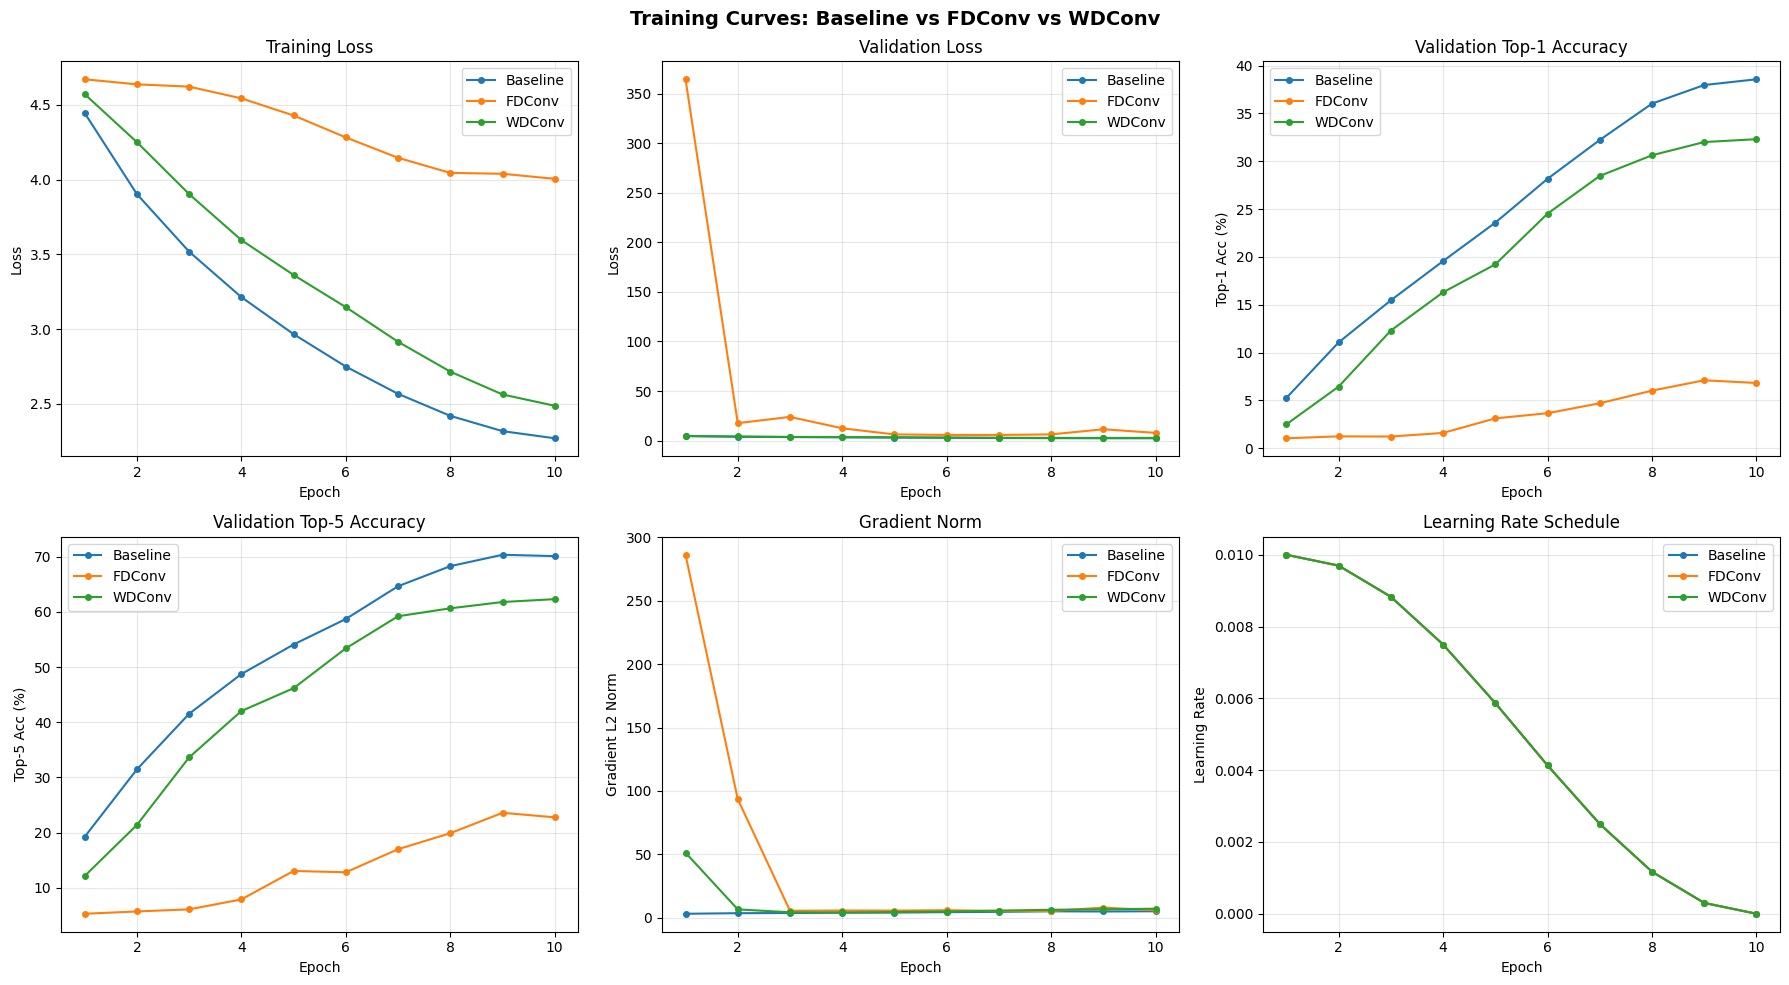

In [ ]:
COLORS = {'Baseline': '#1f77b4', 'FDConv': '#ff7f0e', 'WDConv': '#2ca02c'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Panel 1: Training Loss ---
ax = axes[0, 0]
for name in VARIANTS:
    if not metrics[name]: continue
    epochs = [m['epoch'] for m in metrics[name]]
    vals = [m['train_loss'] for m in metrics[name]]
    ax.plot(epochs, vals, '-o', color=COLORS[name], label=name, markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss'); ax.legend(); ax.grid(True, alpha=0.3)

# --- Panel 2: Validation Loss ---
ax = axes[0, 1]
for name in VARIANTS:
    if not metrics[name]: continue
    epochs = [m['epoch'] for m in metrics[name]]
    vals = [m['val_loss'] for m in metrics[name]]
    ax.plot(epochs, vals, '-o', color=COLORS[name], label=name, markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Validation Loss'); ax.legend(); ax.grid(True, alpha=0.3)

# --- Panel 3: Val Top-1 Accuracy ---
ax = axes[0, 2]
for name in VARIANTS:
    if not metrics[name]: continue
    epochs = [m['epoch'] for m in metrics[name]]
    vals = [m['val_top1'] for m in metrics[name]]
    ax.plot(epochs, vals, '-o', color=COLORS[name], label=name, markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Top-1 Acc (%)')
ax.set_title('Validation Top-1 Accuracy'); ax.legend(); ax.grid(True, alpha=0.3)

# --- Panel 4: Val Top-5 Accuracy ---
ax = axes[1, 0]
for name in VARIANTS:
    if not metrics[name]: continue
    epochs = [m['epoch'] for m in metrics[name]]
    vals = [m['val_top5'] for m in metrics[name]]
    ax.plot(epochs, vals, '-o', color=COLORS[name], label=name, markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Top-5 Acc (%)')
ax.set_title('Validation Top-5 Accuracy'); ax.legend(); ax.grid(True, alpha=0.3)

# --- Panel 5: Gradient Norm ---
ax = axes[1, 1]
for name in VARIANTS:
    if not metrics[name]: continue
    epochs = [m['epoch'] for m in metrics[name]]
    vals = [m['grad_norm'] for m in metrics[name]]
    ax.plot(epochs, vals, '-o', color=COLORS[name], label=name, markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Gradient L2 Norm')
ax.set_title('Gradient Norm'); ax.legend(); ax.grid(True, alpha=0.3)

# --- Panel 6: Learning Rate ---
ax = axes[1, 2]
for name in VARIANTS:
    if not metrics[name]: continue
    epochs = [m['epoch'] for m in metrics[name]]
    vals = [m['lr'] for m in metrics[name]]
    ax.plot(epochs, vals, '-o', color=COLORS[name], label=name, markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves: Baseline vs FDConv vs WDConv', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Visualization: Loss Curves (per iteration)

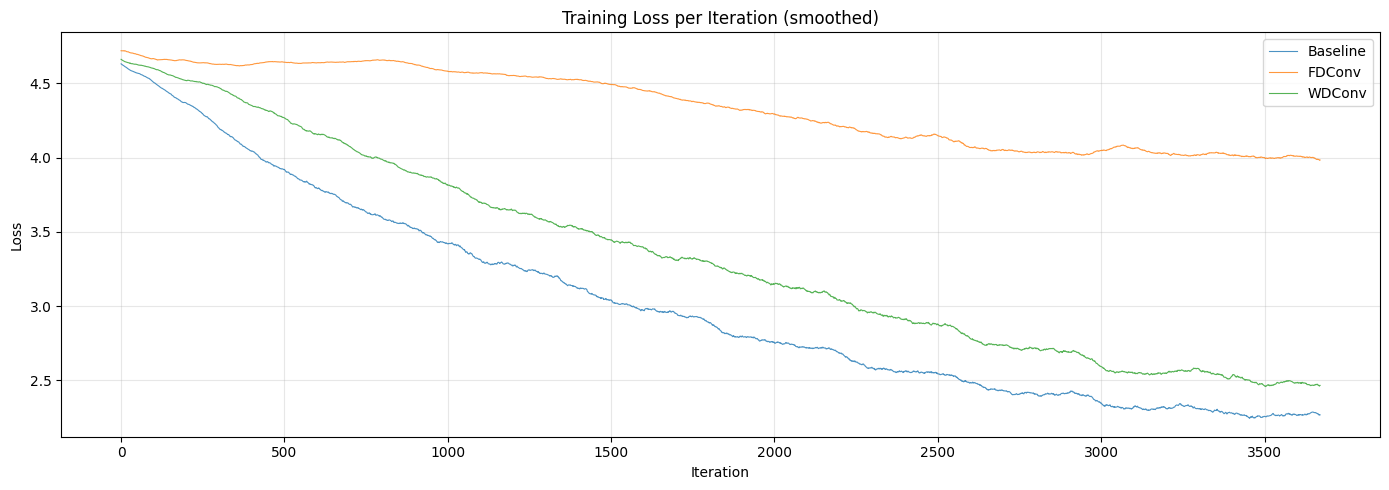

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

for name in VARIANTS:
    if not losses[name]: continue
    # Smooth with moving average
    raw = np.array(losses[name])
    window = min(100, len(raw) // 10)
    if window > 1:
        smooth = np.convolve(raw, np.ones(window) / window, mode='valid')
        ax.plot(smooth, color=COLORS[name], label=name, alpha=0.8, linewidth=0.8)
    else:
        ax.plot(raw, color=COLORS[name], label=name, alpha=0.8, linewidth=0.8)

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Training Loss per Iteration (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Table

In [ ]:
rows = []
baseline_top1 = None

for name in VARIANTS:
    if not metrics[name]:
        continue

    best_epoch = max(metrics[name], key=lambda m: m['val_top1'])
    last_epoch = metrics[name][-1]
    info = model_infos_loaded.get(name, model_infos.get(name, {}))
    bench = bench_results.get(name, {})

    if name == 'Baseline':
        baseline_top1 = best_epoch['val_top1']

    total_time = last_epoch.get('cumulative_time_sec', 0)

    rows.append({
        'Variant': name,
        'Params (M)': info.get('total_params_M', '-'),
        'Best Val Top-1 (%)': best_epoch['val_top1'],
        'Best Val Top-5 (%)': best_epoch['val_top5'],
        'Delta Top-1 (%)': round(best_epoch['val_top1'] - baseline_top1, 2) if baseline_top1 else '-',
        'Best Epoch': best_epoch['epoch'],
        'Train Loss (last)': last_epoch['train_loss'],
        'Val Loss (best)': best_epoch['val_loss'],
        'Inference (img/s)': round(bench.get('throughput_img_s', 0), 0),
        'Total Time (min)': round(total_time / 60, 1),
    })

df_summary = pd.DataFrame(rows)
display(df_summary)

# Save as CSV for the paper
df_summary.to_csv(os.path.join(OUTPUT_DIR, 'summary_table.csv'), index=False)
print(f'\nSaved to {OUTPUT_DIR}/summary_table.csv')

,Variant,Params (M),Best Val Top-1 (%),Best Val Top-5 (%),Delta Top-1 (%),Best Epoch,Train Loss (last),Val Loss (best),Inference (img/s),Total Time (min)
0,Baseline,11.220,38.56,70.12,0.00,10,2.2702,2.3525,9658.0,4.3
1,FDConv,11.808,7.10,23.60,-31.46,9,4.0052,11.4297,391.0,44.5
2,WDConv,11.783,32.30,62.32,-6.26,10,2.4874,2.6773,351.0,56.0



Saved to /content/drive/MyDrive/FDConv/runs/summary_table.csv


## 10. Bar Charts: Final Comparison

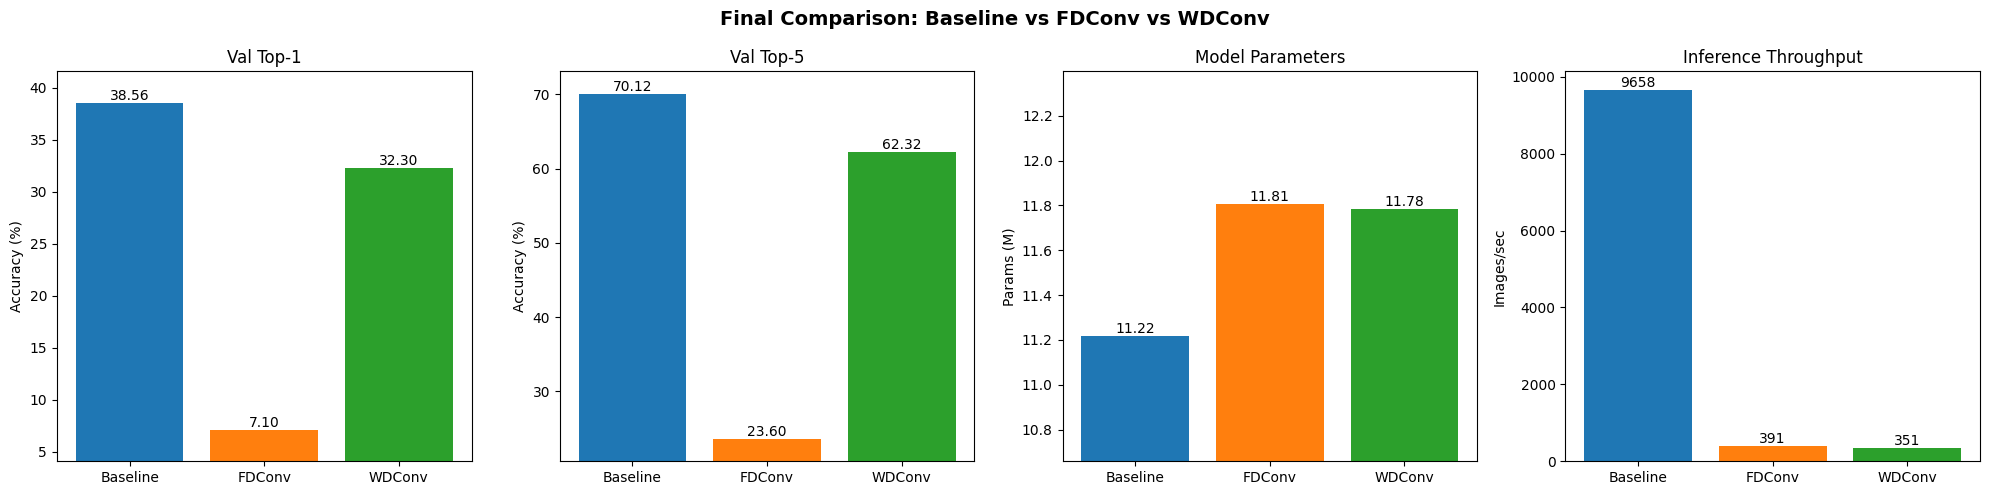

In [ ]:
if len(df_summary) >= 2:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    names = df_summary['Variant'].tolist()
    colors = [COLORS[n] for n in names]
    x = range(len(names))

    # Top-1
    vals = df_summary['Best Val Top-1 (%)'].tolist()
    bars = axes[0].bar(x, vals, color=colors)
    axes[0].bar_label(bars, fmt='%.2f')
    axes[0].set_xticks(x); axes[0].set_xticklabels(names)
    axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Val Top-1')
    axes[0].set_ylim(min(vals) - 3, max(vals) + 3)

    # Top-5
    vals = df_summary['Best Val Top-5 (%)'].tolist()
    bars = axes[1].bar(x, vals, color=colors)
    axes[1].bar_label(bars, fmt='%.2f')
    axes[1].set_xticks(x); axes[1].set_xticklabels(names)
    axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Val Top-5')
    axes[1].set_ylim(min(vals) - 3, max(vals) + 3)

    # Params
    vals = [float(v) for v in df_summary['Params (M)'].tolist()]
    bars = axes[2].bar(x, vals, color=colors)
    axes[2].bar_label(bars, fmt='%.2f')
    axes[2].set_xticks(x); axes[2].set_xticklabels(names)
    axes[2].set_ylabel('Params (M)'); axes[2].set_title('Model Parameters')
    axes[2].set_ylim(min(vals) * 0.95, max(vals) * 1.05)

    # Throughput
    vals = df_summary['Inference (img/s)'].tolist()
    bars = axes[3].bar(x, vals, color=colors)
    axes[3].bar_label(bars, fmt='%.0f')
    axes[3].set_xticks(x); axes[3].set_xticklabels(names)
    axes[3].set_ylabel('Images/sec'); axes[3].set_title('Inference Throughput')

    plt.suptitle('Final Comparison: Baseline vs FDConv vs WDConv',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'final_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough data to plot. Train at least 2 variants.')

## 11. Throughput vs Accuracy Scatter

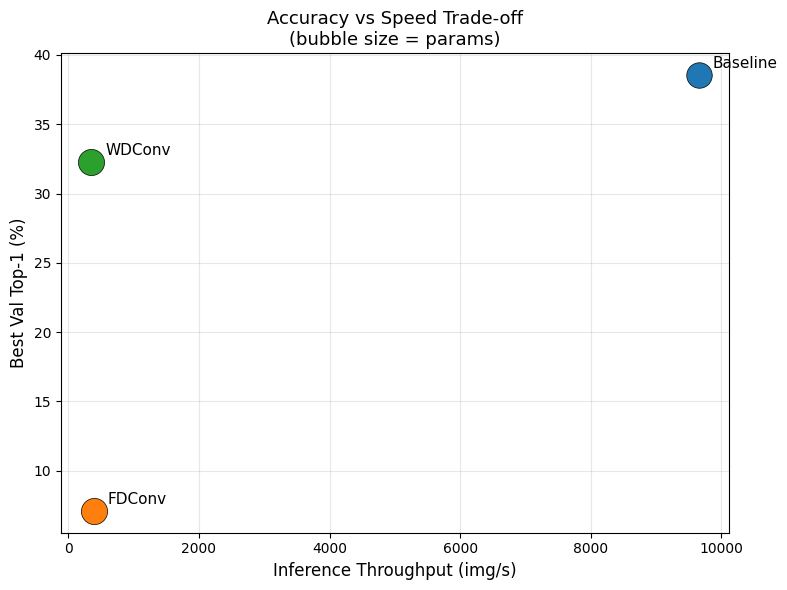

In [ ]:
if len(df_summary) >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    for _, row in df_summary.iterrows():
        name = row['Variant']
        ax.scatter(row['Inference (img/s)'], row['Best Val Top-1 (%)'],
                   s=float(row['Params (M)']) * 30, color=COLORS[name],
                   edgecolors='black', linewidth=0.5, zorder=5)
        ax.annotate(name, (row['Inference (img/s)'], row['Best Val Top-1 (%)']),
                    textcoords='offset points', xytext=(10, 5), fontsize=11)

    ax.set_xlabel('Inference Throughput (img/s)', fontsize=12)
    ax.set_ylabel('Best Val Top-1 (%)', fontsize=12)
    ax.set_title('Accuracy vs Speed Trade-off\n(bubble size = params)', fontsize=13)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'accuracy_vs_speed.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 12. Sample Predictions

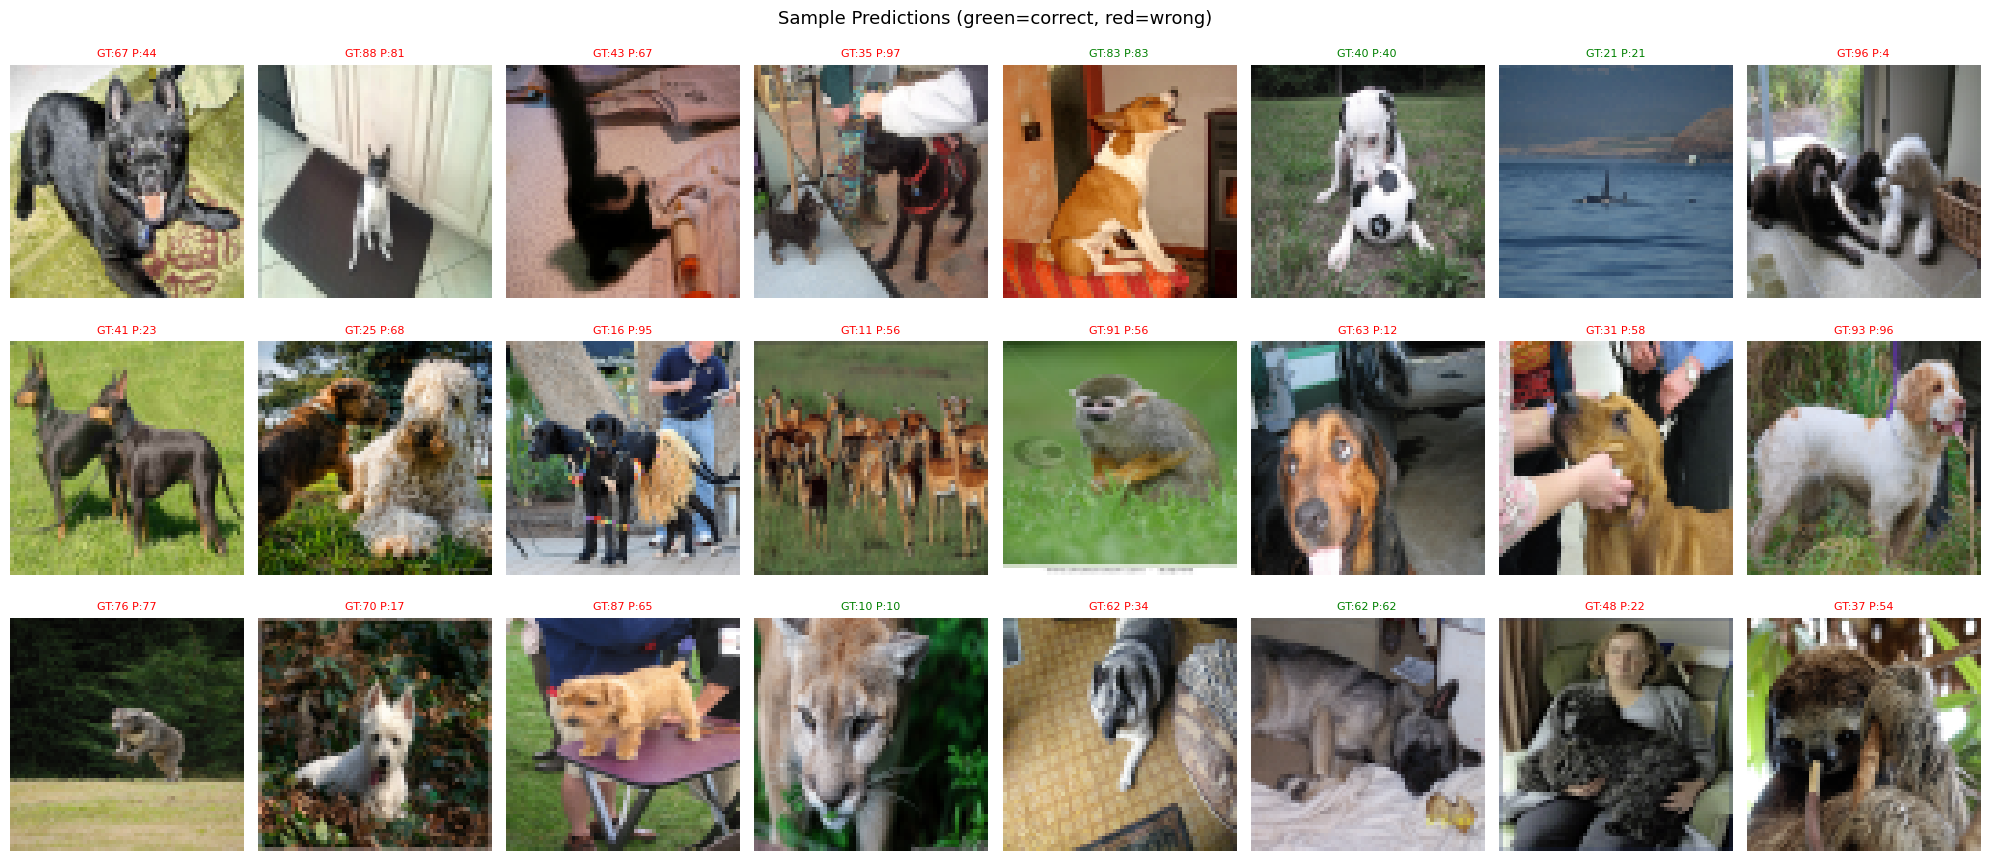

In [ ]:
@torch.inference_mode()
def get_predictions(model, dataset, device, n=16):
    model.eval()
    model.to(device)
    indices = random.sample(range(len(dataset)), n)
    images, labels, preds = [], [], []
    for idx in indices:
        img, lbl = dataset[idx]
        logit = model(img.unsqueeze(0).to(device))
        pred = logit.argmax(1).item()
        # Denormalize for display
        img_show = img * dataset.STD + dataset.MEAN
        img_show = img_show.clamp(0, 1).permute(1, 2, 0).numpy()
        images.append(img_show)
        labels.append(lbl)
        preds.append(pred)
    return images, labels, preds


fig, axes = plt.subplots(len(VARIANTS), 8, figsize=(20, 3 * len(VARIANTS)))
if len(VARIANTS) == 1:
    axes = axes[np.newaxis, :]

random.seed(SEED)
for row, name in enumerate(VARIANTS):
    model = all_models[name]
    imgs, lbls, pds = get_predictions(model, val_dataset, device, n=8)
    for col in range(8):
        ax = axes[row, col]
        ax.imshow(imgs[col])
        correct = lbls[col] == pds[col]
        color = 'green' if correct else 'red'
        ax.set_title(f'GT:{lbls[col]} P:{pds[col]}', fontsize=8, color=color)
        ax.axis('off')
    axes[row, 0].set_ylabel(name, fontsize=12, rotation=0, labelpad=50)

plt.suptitle('Sample Predictions (green=correct, red=wrong)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Weight Domain Visualization

Visualize the learned weight representations:
- **FDConv**: DFT spectrum (magnitude of complex Fourier coefficients)
- **WDConv**: DWT subbands (LL, LH, HL, HH real wavelet coefficients)

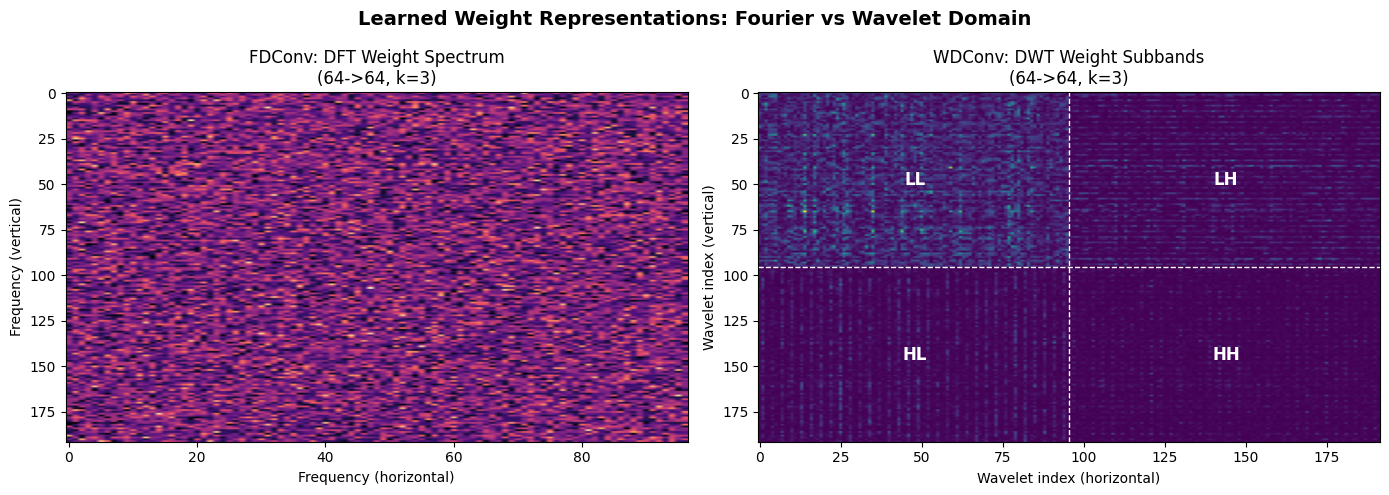

In [ ]:
from wdconv import haar_dwt2d_pack

def get_first_dynamic_layer(model, conv_type):
    """Find first dynamically-replaced conv layer."""
    for m in model.modules():
        if isinstance(m, conv_type) and hasattr(m, 'KSM_Global'):
            return m
    return None


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FDConv: DFT spectrum
fd_layer = get_first_dynamic_layer(all_models['FDConv'], FDConv)
if fd_layer is not None and hasattr(fd_layer, 'dft_weight'):
    w = fd_layer.dft_weight[0].detach().cpu()  # (H, W_rfft, 2)
    if w.dim() == 3:
        magnitude = (w[..., 0] ** 2 + w[..., 1] ** 2).sqrt()
    else:
        magnitude = w.abs()
    axes[0].imshow(magnitude.log1p().numpy(), cmap='magma', aspect='auto')
    axes[0].set_title(f'FDConv: DFT Weight Spectrum\n({fd_layer.in_channels}->{fd_layer.out_channels}, k={fd_layer.kernel_size[0]})')
    axes[0].set_xlabel('Frequency (horizontal)')
    axes[0].set_ylabel('Frequency (vertical)')
else:
    axes[0].text(0.5, 0.5, 'No FDConv layer found', ha='center', va='center')
    axes[0].set_title('FDConv: DFT Spectrum')

# WDConv: DWT subbands
wd_layer = get_first_dynamic_layer(all_models['WDConv'], WDConv)
if wd_layer is not None and hasattr(wd_layer, 'dwt_weight'):
    w = wd_layer.dwt_weight[0].detach().cpu()  # (H, W) real
    im = axes[1].imshow(w.abs().log1p().numpy(), cmap='viridis', aspect='auto')
    h2, w2 = w.shape[-2] // 2, w.shape[-1] // 2
    axes[1].axhline(y=h2 - 0.5, color='white', linewidth=1, linestyle='--')
    axes[1].axvline(x=w2 - 0.5, color='white', linewidth=1, linestyle='--')
    axes[1].text(w2 // 2, h2 // 2, 'LL', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    axes[1].text(w2 + w2 // 2, h2 // 2, 'LH', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    axes[1].text(w2 // 2, h2 + h2 // 2, 'HL', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    axes[1].text(w2 + w2 // 2, h2 + h2 // 2, 'HH', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    axes[1].set_title(f'WDConv: DWT Weight Subbands\n({wd_layer.in_channels}->{wd_layer.out_channels}, k={wd_layer.kernel_size[0]})')
    axes[1].set_xlabel('Wavelet index (horizontal)')
    axes[1].set_ylabel('Wavelet index (vertical)')
else:
    axes[1].text(0.5, 0.5, 'No WDConv layer found', ha='center', va='center')
    axes[1].set_title('WDConv: DWT Subbands')

plt.suptitle('Learned Weight Representations: Fourier vs Wavelet Domain',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'weight_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()

## 14. Training Time Comparison

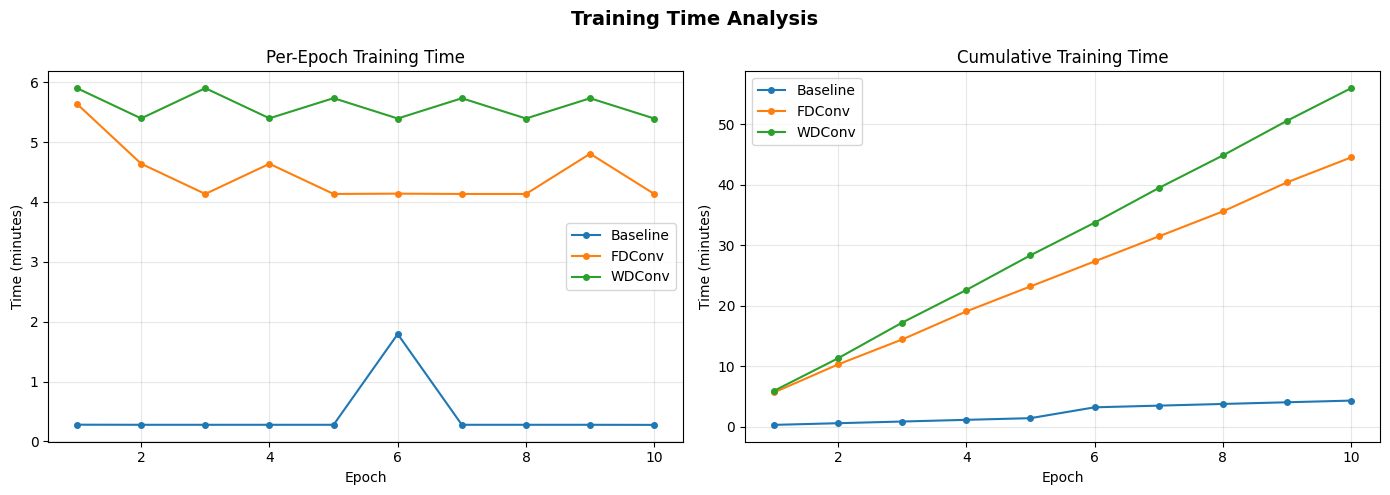

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-epoch training time
ax = axes[0]
for name in VARIANTS:
    if not metrics[name]: continue
    epochs = [m['epoch'] for m in metrics[name]]
    times = [m['epoch_time_sec'] / 60 for m in metrics[name]]
    ax.plot(epochs, times, '-o', color=COLORS[name], label=name, markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Time (minutes)')
ax.set_title('Per-Epoch Training Time'); ax.legend(); ax.grid(True, alpha=0.3)

# Cumulative time
ax = axes[1]
for name in VARIANTS:
    if not metrics[name]: continue
    epochs = [m['epoch'] for m in metrics[name]]
    times = [m['cumulative_time_sec'] / 60 for m in metrics[name]]
    ax.plot(epochs, times, '-o', color=COLORS[name], label=name, markersize=4)
ax.set_xlabel('Epoch'); ax.set_ylabel('Time (minutes)')
ax.set_title('Cumulative Training Time'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training Time Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_time.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Throughput Comparison (Training vs Inference)

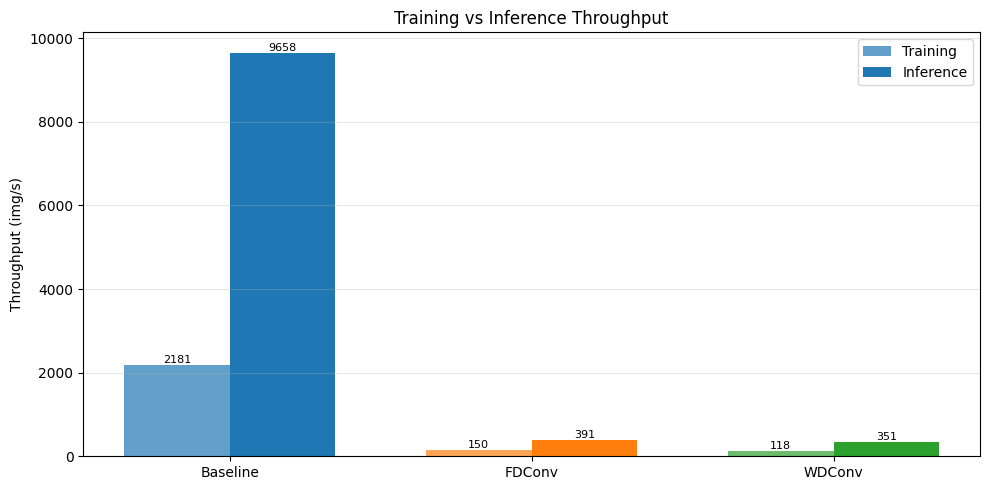

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(VARIANTS))
width = 0.35

train_throughputs = []
infer_throughputs = []

for name in VARIANTS:
    if metrics[name]:
        avg_train_tp = np.mean([m['train_throughput'] for m in metrics[name]])
    else:
        avg_train_tp = 0
    train_throughputs.append(avg_train_tp)
    infer_throughputs.append(bench_results.get(name, {}).get('throughput_img_s', 0))

bars1 = ax.bar(x - width/2, train_throughputs, width, label='Training',
               color=[COLORS[n] for n in VARIANTS], alpha=0.7)
bars2 = ax.bar(x + width/2, infer_throughputs, width, label='Inference',
               color=[COLORS[n] for n in VARIANTS], alpha=1.0)

ax.bar_label(bars1, fmt='%.0f', fontsize=8)
ax.bar_label(bars2, fmt='%.0f', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(VARIANTS)
ax.set_ylabel('Throughput (img/s)')
ax.set_title('Training vs Inference Throughput')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'throughput_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Download Results

In [ ]:
# Package all results into a zip file for download
import shutil

# List saved artifacts
print('Saved artifacts:')
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        fpath = os.path.join(root, file)
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'{subindent}{file} ({size_mb:.1f} MB)')

# Create zip (exclude large checkpoint files)
zip_path = '/content/fdconv_results'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
print(f'\nResults packaged: {zip_path}.zip')

# Download (uncomment in Colab)
# from google.colab import files
# files.download(f'{zip_path}.zip')

Saved artifacts:
runs/
  variant_times.json (0.0 MB)
  benchmark_results.json (0.0 MB)
  training_curves.png (0.3 MB)
  loss_curves.png (0.1 MB)
  summary_table.csv (0.0 MB)
  final_comparison.png (0.1 MB)
  accuracy_vs_speed.png (0.1 MB)
  sample_predictions.png (0.4 MB)
  weight_visualization.png (1.4 MB)
  training_time.png (0.1 MB)
  throughput_comparison.png (0.0 MB)
  Baseline/
    model_info.json (0.0 MB)
    config.json (0.0 MB)
    metrics.json (0.0 MB)
    losses.json (0.1 MB)
    last.pth (89.8 MB)
    best.pth (89.8 MB)
  FDConv/
    model_info.json (0.0 MB)
    config.json (0.0 MB)
    metrics.json (0.0 MB)
    losses.json (0.1 MB)
    last.pth (94.8 MB)
    best.pth (94.8 MB)
  WDConv/
    model_info.json (0.0 MB)
    config.json (0.0 MB)
    metrics.json (0.0 MB)
    losses.json (0.1 MB)
    last.pth (94.6 MB)
    best.pth (94.6 MB)

Results packaged: /content/fdconv_results.zip
